<a href="https://colab.research.google.com/github/ayshibashi/unmsm-research-methods-angela-yshibashi/blob/main/clasificacion_documentos_pdf_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación de documentos PDF mediante embeddings y Machine Learning

## Objetivo

Desarrollar un modelo capaz de determinar si un documento PDF es relevante o no relevante para temas como:

- Sistemas de pago.
- Gestión de riesgos.
- Inteligencia artificial.
- Protección de datos.
- Transformación digital.
- Ciberdefensa.

El modelo utilizará embeddings para representar semánticamente el contenido de cada documento y algoritmos de Machine Learning para realizar la clasificación.

## Resultado esperado

Para cada PDF nuevo, el sistema mostrará:

- Clasificación: relevante o no relevante.
- Etiqueta: 1 o 0.
- Probabilidad de relevancia.
- Tema más cercano, si el documento es relevante.
- Similitud temática.
-

In [1]:
# Instalación de las librerías necesarias

!pip install -q pymupdf sentence-transformers joblib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 51.1 MB/s eta 0:00:00


In [2]:
# Conectar Google Colab con Google Drive

from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


### Librerías para trabajar con archivos y rutas


In [3]:
# Manejo de rutas y texto
from pathlib import Path
import re
import hashlib
import warnings

# Procesamiento de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt

# Lectura de PDF
import fitz

# Barra de progreso
from tqdm.auto import tqdm

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Evaluación
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

# Similitud
from sklearn.metrics.pairwise import cosine_similarity

# Embeddings
from sentence_transformers import SentenceTransformer

# Guardado del modelo
import joblib

warnings.filterwarnings("ignore")

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


# Etapa 1: configuración del proyecto en Google Colab

En esta etapa se conecta el notebook con la carpeta del proyecto almacenada en Google Drive y se configuran las rutas de datos, resultados, caché y modelos.

In [4]:
# Carpeta principal del proyecto en Google Drive

RUTA_PROYECTO = Path(
    "/content/drive/MyDrive/Modelo_ML"
)

# Carpetas de datos

RUTA_DATA = RUTA_PROYECTO / "Data"
RUTA_RELEVANTES = RUTA_DATA / "relevantes"
RUTA_NO_RELEVANTES = RUTA_DATA / "no_relevantes"

# Carpetas de salida

RUTA_RESULTADOS = RUTA_PROYECTO / "resultados"
RUTA_MODELOS = RUTA_PROYECTO / "modelos"
RUTA_CACHE = RUTA_PROYECTO / "cache"

# Crear toda la estructura si aún no existe

rutas_proyecto = [
    RUTA_RELEVANTES,
    RUTA_NO_RELEVANTES,
    RUTA_RESULTADOS,
    RUTA_MODELOS,
    RUTA_CACHE
]

for ruta in rutas_proyecto:
    ruta.mkdir(parents=True, exist_ok=True)

print("Estructura del proyecto preparada correctamente.")
print("Ruta principal:", RUTA_PROYECTO)

Proyecto configurado correctamente.
Ruta del proyecto: /content/drive/MyDrive/Modelo_ML


# Etapa 2: construcción del inventario de documentos

Se recorrerán las carpetas de documentos relevantes y no relevantes para crear un inventario con la ruta, etiqueta y tema de cada PDF.

#Función para registrar PDF

In [6]:
def obtener_documentos_pdf(ruta_base, etiqueta):
    """
    Registra los archivos PDF encontrados en una carpeta
    y en todas sus subcarpetas.
    """

    documentos = []

    archivos_pdf = sorted(
        archivo
        for archivo in ruta_base.rglob("*")
        if archivo.is_file()
        and archivo.suffix.lower() == ".pdf"
    )

    for ruta_pdf in archivos_pdf:

        if etiqueta == 1:
            tema = ruta_pdf.parent.name
            clasificacion = "Relevante"
        else:
            tema = "No relevante"
            clasificacion = "No relevante"

        documentos.append({
            "archivo": ruta_pdf.name,
            "ruta": str(ruta_pdf),
            "etiqueta": etiqueta,
            "clasificacion": clasificacion,
            "tema": tema
        })

    return documentos

# Crear el inventario completo

In [8]:
# Registrar ambas clases

documentos_relevantes = obtener_documentos_pdf(
    RUTA_RELEVANTES,
    etiqueta=1
)

documentos_no_relevantes = obtener_documentos_pdf(
    RUTA_NO_RELEVANTES,
    etiqueta=0
)

# Construir el inventario

df_documentos = pd.DataFrame(
    documentos_relevantes
    + documentos_no_relevantes
)

if df_documentos.empty:
    raise ValueError(
        "No se encontraron archivos PDF en las carpetas configuradas."
    )

print("Inventario creado correctamente.")
print("Total de documentos:", len(df_documentos))

display(
    df_documentos["clasificacion"]
    .value_counts()
    .rename_axis("clase")
    .reset_index(name="cantidad")
)

df_documentos.head()

Inventario creado correctamente.
Total de documentos: 150


,clase,cantidad
0,Relevante,75
1,No relevante,75


,archivo,ruta,etiqueta,clasificacion,tema
0,Circular-002-2006-BCRP.pdf,/content/drive/MyDrive/Modelo_ML/Data/relevant...,1,Relevante,BCRP SISTEMA DE PAGOS
1,Circular-007-2007-BCRP.pdf,/content/drive/MyDrive/Modelo_ML/Data/relevant...,1,Relevante,BCRP SISTEMA DE PAGOS
2,Circular-017-2005-BCRP.pdf,/content/drive/MyDrive/Modelo_ML/Data/relevant...,1,Relevante,BCRP SISTEMA DE PAGOS
3,Circular-024-2001-BCRP.pdf,/content/drive/MyDrive/Modelo_ML/Data/relevant...,1,Relevante,BCRP SISTEMA DE PAGOS
4,circular-0002-2024-bcrp.pdf,/content/drive/MyDrive/Modelo_ML/Data/relevant...,1,Relevante,BCRP SISTEMA DE PAGOS


## Distribución inicial de los documentos

Se analizará la cantidad de documentos disponibles por clase y por tema antes de iniciar la extracción del texto.

In [11]:
# Conteo de documentos por tema

conteo_temas = (
    df_documentos["tema"]
    .value_counts()
    .rename_axis("tema")
    .reset_index(name="cantidad")
)

print("\nDistribución por tema:")
display(conteo_temas)


Distribución por tema:


,tema,cantidad
0,No relevante,75
1,BCRP SISTEMA DE PAGOS,22
2,SBS GESTION DE RIESGOS,21
3,PCM TRANSFORMACION DIGITAL,19
4,PCM IA,8
5,PCM PROTECCION DE DATOS,4
6,CIBERDEFENSA,1


# Gráfico por clase

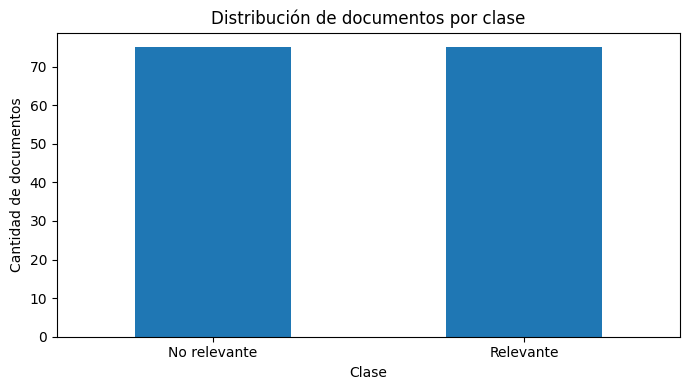

In [12]:
# Gráfico de cantidad de documentos por clase

conteo_clases.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Distribución de documentos por clase")
plt.xlabel("Clase")
plt.ylabel("Cantidad de documentos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Gráfico por tema

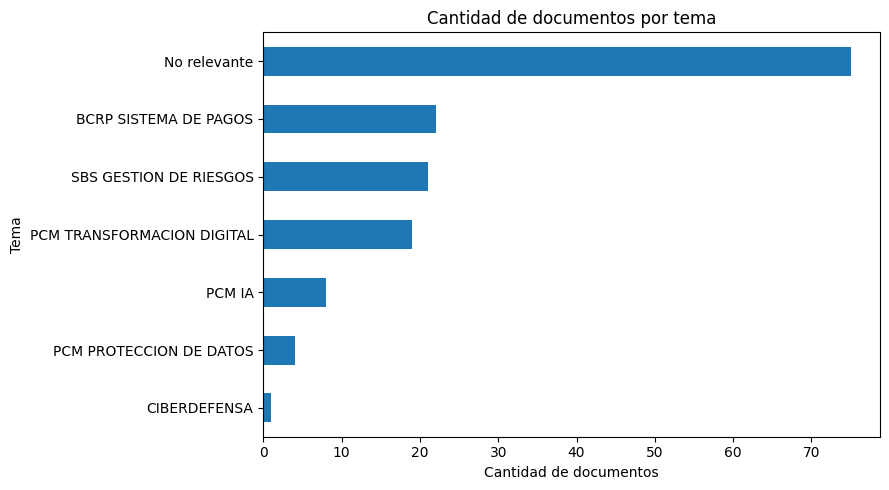

In [13]:
# Gráfico de cantidad de documentos por tema

conteo_temas_ordenado = (
    df_documentos["tema"]
    .value_counts()
    .sort_values(ascending=True)
)

conteo_temas_ordenado.plot(
    kind="barh",
    figsize=(9, 5)
)

plt.title("Cantidad de documentos por tema")
plt.xlabel("Cantidad de documentos")
plt.ylabel("Tema")
plt.tight_layout()
plt.show()

## Guardado del inventario inicial

El inventario contiene el nombre, la ruta, la etiqueta y el tema de todos los documentos encontrados.

In [14]:
# Guardar el inventario inicial

ruta_inventario = (
    RUTA_RESULTADOS / "inventario_documentos.csv"
)

df_documentos.to_csv(
    ruta_inventario,
    index=False,
    encoding="utf-8-sig"
)

print("Inventario guardado correctamente en:")
print(ruta_inventario)

Inventario guardado correctamente en:
/content/drive/MyDrive/Modelo_ML/resultados/inventario_documentos.csv


# Etapa 3: extracción y validación del texto

En esta etapa se extraerá el contenido textual de todos los documentos PDF.

Para cada archivo se registrará:

- Número de páginas.
- Cantidad de caracteres.
- Cantidad de palabras.
- Estado de extracción.
- Mensaje de error, cuando corresponda.

Los documentos sin texto extraíble o con contenido insuficiente serán identificados automáticamente y no se utilizarán durante el entrenamiento.

# Limpieza y extracción

In [15]:
def limpiar_texto(texto):
    """
    Realiza una limpieza básica del texto extraído.

    Conserva el contenido semántico y elimina espacios,
    tabulaciones y saltos de línea innecesarios.
    """

    if not isinstance(texto, str):
        return ""

    texto = texto.replace("\x00", " ")
    texto = re.sub(r"\s+", " ", texto)
    texto = texto.strip()

    return texto


def extraer_informacion_pdf(ruta_pdf):
    """
    Extrae el texto y las características principales de un PDF.

    Retorna
    -------
    dict
        Texto, número de páginas, palabras, caracteres,
        estado de extracción y mensaje de error.
    """

    resultado = {
        "texto": "",
        "numero_paginas": 0,
        "cantidad_palabras": 0,
        "cantidad_caracteres": 0,
        "estado_extraccion": "Error",
        "mensaje_error": ""
    }

    documento = None

    try:
        ruta_pdf = Path(ruta_pdf)

        if not ruta_pdf.exists():
            raise FileNotFoundError(
                f"No se encontró el archivo: {ruta_pdf}"
            )

        documento = fitz.open(ruta_pdf)

        resultado["numero_paginas"] = documento.page_count

        textos_paginas = [
            pagina.get_text("text")
            for pagina in documento
        ]

        texto_completo = "\n".join(textos_paginas)
        texto_limpio = limpiar_texto(texto_completo)

        cantidad_palabras = len(texto_limpio.split())
        cantidad_caracteres = len(texto_limpio)

        resultado["texto"] = texto_limpio
        resultado["cantidad_palabras"] = cantidad_palabras
        resultado["cantidad_caracteres"] = cantidad_caracteres

        if cantidad_caracteres == 0:
            resultado["estado_extraccion"] = "Sin texto"

        elif cantidad_palabras < 50:
            resultado["estado_extraccion"] = "Texto insuficiente"

        else:
            resultado["estado_extraccion"] = "Correcto"

    except Exception as error:
        resultado["estado_extraccion"] = "Error"
        resultado["mensaje_error"] = str(error)

    finally:
        if documento is not None:
            documento.close()

    return resultado


print("Funciones de extracción creadas correctamente.")

Funciones de extracción creadas correctamente.


# Extraer todos los documentos y unir los resultados

In [16]:
# Extraer el texto de todos los documentos

resultados_extraccion = []

print("Iniciando extracción de documentos...\n")

for ruta_pdf in tqdm(
    df_documentos["ruta"],
    total=len(df_documentos),
    desc="Procesando PDF"
):
    resultados_extraccion.append(
        extraer_informacion_pdf(ruta_pdf)
    )

# Convertir los resultados en DataFrame

df_extraccion = pd.DataFrame(
    resultados_extraccion
)

# Unir inventario y resultados de extracción

df_documentos = pd.concat(
    [
        df_documentos.reset_index(drop=True),
        df_extraccion.reset_index(drop=True)
    ],
    axis=1
)

print("\nExtracción finalizada.")
print("Documentos procesados:", len(df_documentos))

# Mostrar un resumen compacto

resumen_extraccion = (
    df_documentos["estado_extraccion"]
    .value_counts(dropna=False)
    .rename_axis("estado")
    .reset_index(name="cantidad")
)

display(resumen_extraccion)

Iniciando extracción de documentos...



Procesando PDF:   0%|          | 0/150 [00:00<?, ?it/s]


Extracción finalizada.
Documentos procesados: 150


,estado,cantidad
0,Correcto,136
1,Sin texto,14


# Resumen por clase

In [17]:
# Resumen de extracción por clase

resumen_clase_extraccion = (
    df_documentos
    .groupby(
        [
            "clasificacion",
            "estado_extraccion"
        ]
    )
    .size()
    .reset_index(name="cantidad")
)

display(resumen_clase_extraccion)

,clasificacion,estado_extraccion,cantidad
0,No relevante,Correcto,72
1,No relevante,Sin texto,3
2,Relevante,Correcto,64
3,Relevante,Sin texto,11


## Recuperación alternativa de documentos sin texto

Algunos archivos PDF pueden visualizarse correctamente, pero no contener una capa textual que pueda ser extraída mediante PyMuPDF.

Antes de excluir estos documentos, se realizará un segundo intento de recuperación utilizando la biblioteca `pypdf`.

Este procedimiento se aplicará únicamente a los documentos cuyo estado inicial sea:

- Sin texto.
- Texto insuficiente.
- Error de extracción.

Los documentos que tampoco puedan recuperarse mediante este segundo método serán excluidos del conjunto de modelado.

In [18]:
  !pip install -q pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.5/349.5 kB 6.5 MB/s eta 0:00:00


In [19]:
# Métodos de extracción de PDF
import fitz
from pypdf import PdfReader

In [20]:
def extraer_texto_alternativo_pypdf(ruta_pdf):
    """
    Intenta recuperar el contenido textual de un PDF mediante pypdf.

    Esta función se utiliza únicamente cuando la extracción principal
    con PyMuPDF no obtiene texto suficiente.

    Retorna
    -------
    dict
        Texto recuperado, cantidad de palabras, caracteres,
        estado del intento y posible mensaje de error.
    """

    resultado = {
        "texto_alternativo": "",
        "palabras_alternativas": 0,
        "caracteres_alternativos": 0,
        "estado_alternativo": "Sin texto",
        "error_alternativo": ""
    }

    try:
        lector = PdfReader(str(ruta_pdf))
        textos_paginas = []

        for pagina in lector.pages:
            texto_pagina = pagina.extract_text() or ""
            textos_paginas.append(texto_pagina)

        texto_completo = " ".join(textos_paginas)
        texto_limpio = limpiar_texto(texto_completo)

        cantidad_palabras = len(texto_limpio.split())
        cantidad_caracteres = len(texto_limpio)

        resultado["texto_alternativo"] = texto_limpio
        resultado["palabras_alternativas"] = cantidad_palabras
        resultado["caracteres_alternativos"] = cantidad_caracteres

        if cantidad_caracteres == 0:
            resultado["estado_alternativo"] = "Sin texto"

        elif cantidad_palabras < 50:
            resultado["estado_alternativo"] = "Texto insuficiente"

        else:
            resultado["estado_alternativo"] = "Recuperado"

    except Exception as error:
        resultado["estado_alternativo"] = "Error"
        resultado["error_alternativo"] = str(error)

    return resultado


print("Función de recuperación alternativa creada correctamente.")

Función de recuperación alternativa creada correctamente.


#Reintentamos recuperar todos los documentos problemáticos

In [22]:
# Identificar documentos que necesitan recuperación alternativa

indices_problematicos = df_documentos[
    df_documentos["estado_extraccion"] != "Correcto"
].index

print(
    "Documentos enviados al método alternativo:",
    len(indices_problematicos)
)

resultados_alternativos = []

print("\nIniciando recuperación alternativa con pypdf...\n")

for indice in tqdm(
    indices_problematicos,
    total=len(indices_problematicos),
    desc="Recuperación alternativa"
):
    ruta_pdf = df_documentos.loc[indice, "ruta"]

    resultado = extraer_texto_alternativo_pypdf(
        ruta_pdf
    )

    resultados_alternativos.append({
        "indice_original": indice,
        "archivo": df_documentos.loc[indice, "archivo"],
        **resultado
    })

df_recuperacion = pd.DataFrame(
    resultados_alternativos
)

print("\nSegundo intento finalizado.")

if not df_recuperacion.empty:
    display(
        df_recuperacion["estado_alternativo"]
        .value_counts(dropna=False)
        .rename_axis("resultado")
        .reset_index(name="cantidad")
    )
else:
    print("No había documentos que necesitaran recuperación.")

Documentos enviados al método alternativo: 14

Iniciando recuperación alternativa con pypdf...



Recuperación alternativa:   0%|          | 0/14 [00:00<?, ?it/s]


Segundo intento finalizado.


,resultado,cantidad
0,Sin texto,14


## Creación del conjunto de documentos válidos

El segundo método de extracción con `pypdf` tampoco logró recuperar contenido textual de los 14 documentos problemáticos.

Por ello, estos archivos serán excluidos temporalmente del conjunto de modelado. No se eliminarán físicamente, sino que se conservarán como evidencia del proceso de validación.

A partir de este punto se trabajará únicamente con los documentos que contienen texto suficiente para generar embeddings y entrenar los modelos de clasificación.

In [24]:
# Incorporar al dataset los documentos recuperados con pypdf

cantidad_recuperados = 0

if not df_recuperacion.empty:

    for _, fila in df_recuperacion.iterrows():

        if fila["estado_alternativo"] == "Recuperado":

            indice = int(fila["indice_original"])

            df_documentos.loc[
                indice,
                "texto"
            ] = fila["texto_alternativo"]

            df_documentos.loc[
                indice,
                "cantidad_palabras"
            ] = fila["palabras_alternativas"]

            df_documentos.loc[
                indice,
                "cantidad_caracteres"
            ] = fila["caracteres_alternativos"]

            df_documentos.loc[
                indice,
                "estado_extraccion"
            ] = "Correcto con pypdf"

            df_documentos.loc[
                indice,
                "mensaje_error"
            ] = ""

            cantidad_recuperados += 1

print(
    "Documentos recuperados mediante pypdf:",
    cantidad_recuperados
)

Documentos recuperados mediante pypdf: 0


# Crear el conjunto válido

In [25]:
# Estados aceptados para el entrenamiento

estados_validos = [
    "Correcto",
    "Correcto con pypdf"
]

# Documentos que sí se utilizarán en el modelado

df_modelado = (
    df_documentos[
        df_documentos["estado_extraccion"].isin(
            estados_validos
        )
    ]
    .reset_index(drop=True)
    .copy()
)

# Documentos que se excluyen temporalmente

df_excluidos = (
    df_documentos[
        ~df_documentos["estado_extraccion"].isin(
            estados_validos
        )
    ]
    .reset_index(drop=True)
    .copy()
)

# Registrar la decisión metodológica

df_excluidos["decision_modelado"] = (
    "Excluido después de intentar extracción con PyMuPDF y pypdf"
)

print("Conjunto válido creado correctamente.")
print("\nResumen del procesamiento:")
print("- Documentos originales:", len(df_documentos))
print("- Recuperados con pypdf:", cantidad_recuperados)
print("- Documentos válidos:", len(df_modelado))
print("- Documentos excluidos:", len(df_excluidos))

Conjunto válido creado correctamente.

Resumen del procesamiento:
- Documentos originales: 150
- Recuperados con pypdf: 0
- Documentos válidos: 136
- Documentos excluidos: 14


# Mostrar la distribución final por clase y tema

In [26]:
# Distribución final de los documentos válidos

print("Distribución por clase:")

display(
    df_modelado["clasificacion"]
    .value_counts()
    .rename_axis("clase")
    .reset_index(name="cantidad")
)

print("\nDistribución por tema:")

display(
    df_modelado["tema"]
    .value_counts()
    .rename_axis("tema")
    .reset_index(name="cantidad")
)

Distribución por clase:


,clase,cantidad
0,No relevante,72
1,Relevante,64



Distribución por tema:


,tema,cantidad
0,No relevante,72
1,BCRP SISTEMA DE PAGOS,22
2,SBS GESTION DE RIESGOS,21
3,PCM TRANSFORMACION DIGITAL,15
4,PCM PROTECCION DE DATOS,4
5,PCM IA,2


## Guardar la evidencia de recuperación

In [27]:
# Guardar evidencia del segundo método de extracción

ruta_recuperacion = (
    RUTA_RESULTADOS / "intento_recuperacion_pypdf.csv"
)

df_recuperacion.to_csv(
    ruta_recuperacion,
    index=False,
    encoding="utf-8-sig"
)

print("Evidencia de recuperación guardada en:")
print(ruta_recuperacion)

Evidencia de recuperación guardada en:
/content/drive/MyDrive/Modelo_ML/resultados/intento_recuperacion_pypdf.csv


# Guardar los excluidos

In [28]:
# Guardar los documentos excluidos

ruta_excluidos = (
    RUTA_RESULTADOS / "documentos_excluidos.csv"
)

df_excluidos.to_csv(
    ruta_excluidos,
    index=False,
    encoding="utf-8-sig"
)

print("Documentos excluidos guardados en:")
print(ruta_excluidos)

Documentos excluidos guardados en:
/content/drive/MyDrive/Modelo_ML/resultados/documentos_excluidos.csv


#Guardar el dataset válido

In [29]:
# Guardar el conjunto válido con el texto completo

ruta_dataset_valido = (
    RUTA_CACHE / "dataset_documentos_validos.pkl"
)

df_modelado.to_pickle(
    ruta_dataset_valido
)

print("Dataset válido guardado en:")
print(ruta_dataset_valido)

Dataset válido guardado en:
/content/drive/MyDrive/Modelo_ML/cache/dataset_documentos_validos.pkl


# Etapa 4: detección y eliminación de documentos duplicados

Se identificarán documentos con contenido textual idéntico mediante una huella digital o hash.

Los archivos duplicados no serán eliminados físicamente. Se conservará un solo registro de cada contenido para evitar que el modelo aprenda información repetida.

In [30]:
def calcular_hash_texto(texto):
    """
    Genera una huella única a partir del contenido textual
    de cada documento.
    """

    texto_normalizado = re.sub(
        r"\s+",
        " ",
        str(texto).lower().strip()
    )

    return hashlib.sha256(
        texto_normalizado.encode("utf-8")
    ).hexdigest()


df_modelado["hash_texto"] = (
    df_modelado["texto"]
    .apply(calcular_hash_texto)
)

print("Hash generado correctamente.")

Hash generado correctamente.


## Validación rápida de duplicados

In [31]:
documentos_duplicados = df_modelado[
    df_modelado.duplicated(
        subset="hash_texto",
        keep=False
    )
].copy()

print(
    "Registros involucrados en duplicados:",
    len(documentos_duplicados)
)

if not documentos_duplicados.empty:
    display(
        documentos_duplicados[
            [
                "archivo",
                "clasificacion",
                "tema",
                "cantidad_palabras",
                "hash_texto"
            ]
        ].sort_values("hash_texto")
    )
else:
    print("No se encontraron documentos duplicados.")

Registros involucrados en duplicados: 4


,archivo,clasificacion,tema,cantidad_palabras,hash_texto
82,INFORME N 00035 - 2024 - GTI-PRI (1).pdf,No relevante,No relevante,2803,645beb3c1d59739928eadecb787a4ba19f984f303a047f...
83,INFORME N 00035 - 2024 - GTI-PRI.pdf,No relevante,No relevante,2803,645beb3c1d59739928eadecb787a4ba19f984f303a047f...
110,Osinergmin-Evaluacion-PAC-2025-I (1).pdf,No relevante,No relevante,7466,a5c69d8458ccc3150c104e9dbda763eb098067ba9d9c7d...
111,Osinergmin-Evaluacion-PAC-2025-I.pdf,No relevante,No relevante,7466,a5c69d8458ccc3150c104e9dbda763eb098067ba9d9c7d...


# Eliminar duplicados lógicamente

In [32]:
df_modelado_limpio = (
    df_modelado
    .drop_duplicates(
        subset="hash_texto",
        keep="first"
    )
    .reset_index(drop=True)
    .copy()
)

print("Depuración completada.")
print("- Antes:", len(df_modelado))
print("- Después:", len(df_modelado_limpio))
print(
    "- Duplicados eliminados:",
    len(df_modelado) - len(df_modelado_limpio)
)

Depuración completada.
- Antes: 136
- Después: 134
- Duplicados eliminados: 2


# Guardar resultados y obtención del Dataset Limpio

In [33]:
# Guardar evidencia de duplicados

ruta_duplicados = (
    RUTA_RESULTADOS / "documentos_duplicados.csv"
)

documentos_duplicados.to_csv(
    ruta_duplicados,
    index=False,
    encoding="utf-8-sig"
)

# Guardar dataset limpio

ruta_dataset_limpio = (
    RUTA_CACHE / "dataset_modelado_limpio.pkl"
)

df_modelado_limpio.to_pickle(
    ruta_dataset_limpio
)

print("Resultados guardados correctamente.")
print("Duplicados:", ruta_duplicados)
print("Dataset limpio:", ruta_dataset_limpio)

Resultados guardados correctamente.
Duplicados: /content/drive/MyDrive/Modelo_ML/resultados/documentos_duplicados.csv
Dataset limpio: /content/drive/MyDrive/Modelo_ML/cache/dataset_modelado_limpio.pkl


# Etapa 5: división del conjunto de entrenamiento y prueba

El conjunto limpio será dividido en:

- 80 % para entrenamiento.
- 20 % para prueba.

La división será estratificada para conservar la proporción de documentos relevantes y no relevantes en ambos conjuntos.

In [34]:
df_train, df_test = train_test_split(
    df_modelado_limpio,
    test_size=0.20,
    random_state=42,
    stratify=df_modelado_limpio["etiqueta"]
)

df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print("División completada.")
print("- Entrenamiento:", len(df_train))
print("- Prueba:", len(df_test))

División completada.
- Entrenamiento: 107
- Prueba: 27


##Guardar la división

In [35]:
ruta_train = RUTA_CACHE / "documentos_train.pkl"
ruta_test = RUTA_CACHE / "documentos_test.pkl"

df_train.to_pickle(ruta_train)
df_test.to_pickle(ruta_test)

print("Conjuntos guardados correctamente.")
print("Train:", ruta_train)
print("Test:", ruta_test)

Conjuntos guardados correctamente.
Train: /content/drive/MyDrive/Modelo_ML/cache/documentos_train.pkl
Test: /content/drive/MyDrive/Modelo_ML/cache/documentos_test.pkl


# Etapa 6: fragmentación del texto

Cada documento será dividido en fragmentos de aproximadamente 350 palabras con un solapamiento de 50 palabras.

El solapamiento ayuda a conservar el contexto entre fragmentos consecutivos.

###Función de fragmentación

In [36]:
def dividir_texto_en_fragmentos(
    texto,
    tamano_fragmento=350,
    solapamiento=50
):
    """
    Divide un texto en fragmentos de palabras con solapamiento.
    """

    if not isinstance(texto, str) or not texto.strip():
        return []

    if solapamiento >= tamano_fragmento:
        raise ValueError(
            "El solapamiento debe ser menor que el tamaño del fragmento."
        )

    palabras = texto.split()
    fragmentos = []

    paso = tamano_fragmento - solapamiento

    for inicio in range(0, len(palabras), paso):
        fin = inicio + tamano_fragmento

        fragmento = " ".join(
            palabras[inicio:fin]
        ).strip()

        if fragmento:
            fragmentos.append(fragmento)

    return fragmentos

## Fragmentar train y test

In [39]:
df_train["fragmentos"] = df_train["texto"].apply(
    dividir_texto_en_fragmentos
)

df_test["fragmentos"] = df_test["texto"].apply(
    dividir_texto_en_fragmentos
)

df_train["cantidad_fragmentos"] = (
    df_train["fragmentos"].apply(len)
)

df_test["cantidad_fragmentos"] = (
    df_test["fragmentos"].apply(len)
)

print("Fragmentación completada.")
print(
    "Fragmentos de entrenamiento:",
    df_train["cantidad_fragmentos"].sum()
)
print(
    "Fragmentos de prueba:",
    df_test["cantidad_fragmentos"].sum()
)

print(
    "Documentos sin fragmentos:",
    (
        (df_train["cantidad_fragmentos"] == 0).sum()
        + (df_test["cantidad_fragmentos"] == 0).sum()
    )
)

Fragmentación completada.
Fragmentos de entrenamiento: 1994
Fragmentos de prueba: 791
Documentos sin fragmentos: 0


## Guardar documentos fragmentados

In [40]:
ruta_train_fragmentado = (
    RUTA_CACHE / "documentos_train_fragmentados.pkl"
)

ruta_test_fragmentado = (
    RUTA_CACHE / "documentos_test_fragmentados.pkl"
)

df_train.to_pickle(ruta_train_fragmentado)
df_test.to_pickle(ruta_test_fragmentado)

print("Conjuntos fragmentados guardados correctamente.")

Conjuntos fragmentados guardados correctamente.


# Etapa 7: generación de embeddings

Cada fragmento será transformado en un vector numérico mediante un modelo multilingüe de Sentence Transformers.

Luego se calculará el promedio de los embeddings de todos los fragmentos de cada PDF para obtener una única representación por documento.

## Cargar el modelo

In [41]:
NOMBRE_MODELO_EMBEDDINGS = (
    "sentence-transformers/"
    "paraphrase-multilingual-MiniLM-L12-v2"
)

print("Cargando modelo de embeddings...")

modelo_embeddings = SentenceTransformer(
    NOMBRE_MODELO_EMBEDDINGS
)

print("Modelo cargado correctamente.")
print(
    "Dimensión del embedding:",
    modelo_embeddings.get_sentence_embedding_dimension()
)

Cargando modelo de embeddings...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Modelo cargado correctamente.
Dimensión del embedding: 384


## Crear la función de embedding por documento

In [42]:
def generar_embedding_documento(
    fragmentos,
    modelo,
    batch_size=16
):
    """
    Genera un único embedding para un documento completo.

    Primero obtiene el embedding de cada fragmento y luego
    calcula el promedio de todos los vectores.
    """

    if not isinstance(fragmentos, list) or len(fragmentos) == 0:
        raise ValueError(
            "El documento no contiene fragmentos válidos."
        )

    embeddings_fragmentos = modelo.encode(
        fragmentos,
        batch_size=batch_size,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False
    )

    embedding_documento = embeddings_fragmentos.mean(axis=0)

    norma = np.linalg.norm(embedding_documento)

    if norma > 0:
        embedding_documento = (
            embedding_documento / norma
        )

    return embedding_documento.astype(np.float32)

## Generar embeddings de entrenamiento

In [43]:
embeddings_train = []

print("Generando embeddings de entrenamiento...\n")

for fragmentos in tqdm(
    df_train["fragmentos"],
    total=len(df_train),
    desc="Embeddings train"
):
    embedding = generar_embedding_documento(
        fragmentos=fragmentos,
        modelo=modelo_embeddings,
        batch_size=16
    )

    embeddings_train.append(embedding)

print("Embeddings de entrenamiento completados.")

Generando embeddings de entrenamiento...



Embeddings train:   0%|          | 0/107 [00:00<?, ?it/s]

Embeddings de entrenamiento completados.


## Generar embeddings de prueba

In [44]:
embeddings_test = []

print("Generando embeddings de prueba...\n")

for fragmentos in tqdm(
    df_test["fragmentos"],
    total=len(df_test),
    desc="Embeddings test"
):
    embedding = generar_embedding_documento(
        fragmentos=fragmentos,
        modelo=modelo_embeddings,
        batch_size=16
    )

    embeddings_test.append(embedding)

print("Embeddings de prueba completados.")

Generando embeddings de prueba...



Embeddings test:   0%|          | 0/27 [00:00<?, ?it/s]

Embeddings de prueba completados.


## Crear las matrices

In [45]:
X_train = np.vstack(embeddings_train)
X_test = np.vstack(embeddings_test)

y_train = df_train["etiqueta"].to_numpy()
y_test = df_test["etiqueta"].to_numpy()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (107, 384)
X_test: (27, 384)
y_train: (107,)
y_test: (27,)


## Guardar embeddings

In [46]:
np.save(
    RUTA_CACHE / "X_train_embeddings.npy",
    X_train
)

np.save(
    RUTA_CACHE / "X_test_embeddings.npy",
    X_test
)

np.save(
    RUTA_CACHE / "y_train.npy",
    y_train
)

np.save(
    RUTA_CACHE / "y_test.npy",
    y_test
)

df_train["embedding"] = list(X_train)
df_test["embedding"] = list(X_test)

df_train.to_pickle(
    RUTA_CACHE / "documentos_train_con_embeddings.pkl"
)

df_test.to_pickle(
    RUTA_CACHE / "documentos_test_con_embeddings.pkl"
)

print("Embeddings guardados correctamente.")

Embeddings guardados correctamente.


# Etapa 8: entrenamiento de modelos de clasificación

Los embeddings de los documentos serán utilizados para entrenar tres modelos:

- Regresión logística.
- SVM lineal.
- Random Forest.

La variable objetivo es:

- 0: documento no relevante.
- 1: documento relevante.

## Crear los modelos

In [47]:
modelos = {
    "Regresión logística": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "SVM lineal": SVC(
        kernel="linear",
        probability=True,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

print("Modelos creados correctamente.")

Modelos creados correctamente.


## Entrenar los modelos

In [48]:
modelos_entrenados = {}

for nombre, modelo in modelos.items():
    print(f"Entrenando: {nombre}")

    modelo.fit(X_train, y_train)

    modelos_entrenados[nombre] = modelo

print("\nTodos los modelos fueron entrenados.")

Entrenando: Regresión logística
Entrenando: SVM lineal
Entrenando: Random Forest

Todos los modelos fueron entrenados.


# Etapa 9: evaluación y comparación

Los modelos serán evaluados con documentos que no participaron en el entrenamiento.

Se utilizarán las métricas:

- Accuracy.
- Precision.
- Recall.
- F1-score.
- ROC-AUC.

## Función de evaluación

In [49]:
def evaluar_modelo(nombre, modelo, X_test, y_test):
    """
    Evalúa un modelo de clasificación binaria.
    """

    predicciones = modelo.predict(X_test)
    probabilidades = modelo.predict_proba(X_test)[:, 1]

    metricas = {
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, predicciones),
        "precision": precision_score(
            y_test,
            predicciones,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            predicciones,
            zero_division=0
        ),
        "f1_score": f1_score(
            y_test,
            predicciones,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_test,
            probabilidades
        )
    }

    return metricas, predicciones, probabilidades

## Evaluar todos los modelos

In [50]:
resultados_modelos = {}
lista_metricas = []

for nombre, modelo in modelos_entrenados.items():

    metricas, predicciones, probabilidades = evaluar_modelo(
        nombre,
        modelo,
        X_test,
        y_test
    )

    lista_metricas.append(metricas)

    resultados_modelos[nombre] = {
        "predicciones": predicciones,
        "probabilidades": probabilidades
    }

df_metricas = pd.DataFrame(lista_metricas)

df_metricas = df_metricas.sort_values(
    by=["f1_score", "recall", "roc_auc"],
    ascending=False
).reset_index(drop=True)

display(df_metricas.round(4))

,modelo,accuracy,precision,recall,f1_score,roc_auc
0,SVM lineal,1.0000,1.0000,1.0000,1.0000,1.000
1,Random Forest,1.0000,1.0000,1.0000,1.0000,1.000
2,Regresión logística,0.9259,0.9231,0.9231,0.9231,0.989


## Gráfico comparativo de métricas

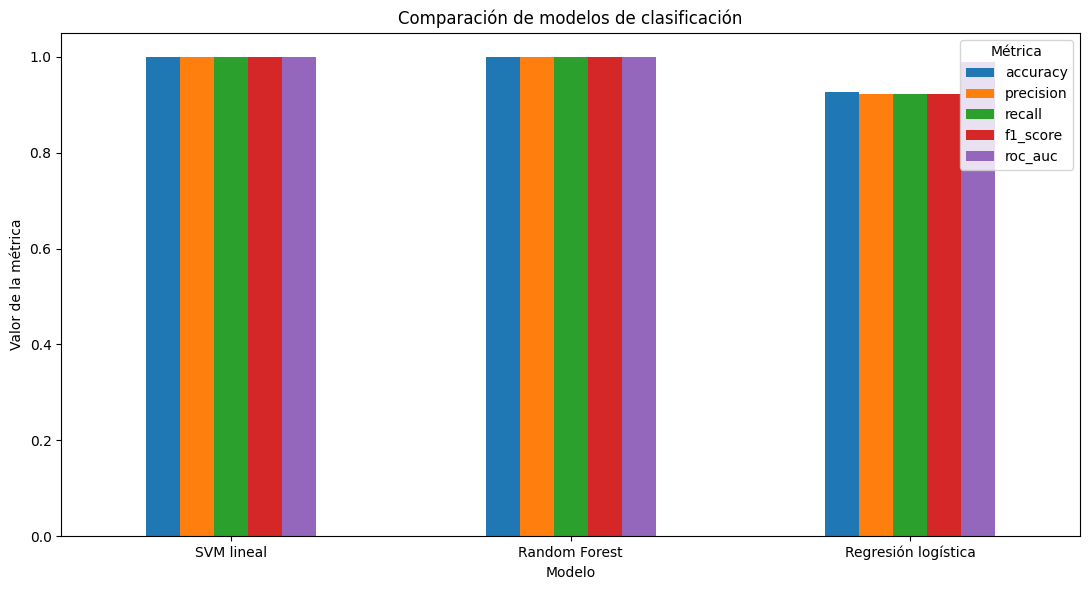

In [51]:
metricas_grafico = (
    df_metricas
    .set_index("modelo")[
        [
            "accuracy",
            "precision",
            "recall",
            "f1_score",
            "roc_auc"
        ]
    ]
)

metricas_grafico.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Comparación de modelos de clasificación")
plt.xlabel("Modelo")
plt.ylabel("Valor de la métrica")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Métrica")
plt.tight_layout()
plt.show()

# Etapa 10: clasificación de un nuevo documento PDF

Se seleccionará el modelo con el mejor F1-score, recall y ROC-AUC.

Posteriormente, se cargará un documento PDF nuevo que no haya participado en el entrenamiento ni en la prueba. El documento será procesado siguiendo exactamente el mismo flujo utilizado durante el entrenamiento:

1. Extracción del texto.
2. Limpieza.
3. Fragmentación.
4. Generación del embedding.
5. Predicción del modelo.
6. Cálculo de la probabilidad de relevancia.

In [53]:
# Seleccionar automáticamente el modelo con mejores métricas
mejor_nombre_modelo = df_metricas.loc[0, "modelo"]
mejor_modelo = modelos_entrenados[
    mejor_nombre_modelo
]

print("Mejor modelo seleccionado:")
print(mejor_nombre_modelo)


Mejor modelo seleccionado:
SVM lineal


##Guardar el mejor modelo

In [54]:
# Guardar el mejor modelo en Google Drive

ruta_mejor_modelo = (
    RUTA_MODELOS / "mejor_modelo_clasificacion.joblib"
)

joblib.dump(
    mejor_modelo,
    ruta_mejor_modelo
)

print("Mejor modelo guardado correctamente en:")
print(ruta_mejor_modelo)

Mejor modelo guardado correctamente en:
/content/drive/MyDrive/Modelo_ML/modelos/mejor_modelo_clasificacion.joblib


## Función para clasificar un PDF nuevo

In [55]:
def clasificar_pdf_nuevo(
    ruta_pdf,
    modelo_clasificacion,
    modelo_embeddings,
    umbral=0.50
):
    """
    Clasifica un documento PDF nuevo como relevante o no relevante.

    Parámetros
    ----------
    ruta_pdf : str o Path
        Ruta del PDF que se desea clasificar.

    modelo_clasificacion
        Modelo de Machine Learning previamente entrenado.

    modelo_embeddings : SentenceTransformer
        Modelo utilizado para generar los embeddings.

    umbral : float
        Probabilidad mínima para clasificar el documento como relevante.

    Retorna
    -------
    dict
        Resultado de la clasificación y características del documento.
    """

    ruta_pdf = Path(ruta_pdf)

    # 1. Extraer información del PDF
    informacion = extraer_informacion_pdf(ruta_pdf)

    if informacion["estado_extraccion"] != "Correcto":
        return {
            "documento": ruta_pdf.name,
            "estado": informacion["estado_extraccion"],
            "mensaje": (
                "No fue posible obtener texto suficiente "
                "para clasificar el documento."
            )
        }

    # 2. Dividir el texto en fragmentos
    fragmentos = dividir_texto_en_fragmentos(
        informacion["texto"],
        tamano_fragmento=350,
        solapamiento=50
    )

    if len(fragmentos) == 0:
        return {
            "documento": ruta_pdf.name,
            "estado": "Sin fragmentos",
            "mensaje": (
                "El documento no generó fragmentos válidos."
            )
        }

    # 3. Generar el embedding del documento
    embedding = generar_embedding_documento(
        fragmentos=fragmentos,
        modelo=modelo_embeddings,
        batch_size=16
    )

    # Convertir a matriz de una sola fila
    X_nuevo = embedding.reshape(1, -1)

    # 4. Obtener probabilidad de relevancia
    probabilidad_relevancia = (
        modelo_clasificacion.predict_proba(X_nuevo)[0, 1]
    )

    # 5. Aplicar el umbral
    etiqueta_predicha = int(
        probabilidad_relevancia >= umbral
    )

    clasificacion = (
        "Relevante"
        if etiqueta_predicha == 1
        else "No relevante"
    )

    return {
        "documento": ruta_pdf.name,
        "estado": "Procesado correctamente",
        "clasificacion": clasificacion,
        "etiqueta": etiqueta_predicha,
        "probabilidad_relevancia": probabilidad_relevancia,
        "numero_paginas": informacion["numero_paginas"],
        "cantidad_palabras": informacion["cantidad_palabras"],
        "cantidad_fragmentos": len(fragmentos)
    }


print("Función de clasificación creada correctamente.")

Función de clasificación creada correctamente.


## Subir el PDF validar el archivo y obtener su ruta

In [58]:
from google.colab import files

print("Selecciona un documento PDF para clasificar.")

archivos_subidos = files.upload()

# Obtener el nombre del archivo subido

if len(archivos_subidos) == 0:
    raise ValueError(
        "No se seleccionó ningún archivo."
    )

nombre_pdf_nuevo = next(
    iter(archivos_subidos.keys())
)

ruta_pdf_nuevo = Path(
    "/content"
) / nombre_pdf_nuevo

if ruta_pdf_nuevo.suffix.lower() != ".pdf":
    raise ValueError(
        "El archivo seleccionado no tiene extensión PDF."
    )

print("Documento cargado correctamente:")
print(ruta_pdf_nuevo)

Selecciona un documento PDF para clasificar.


Saving moneda-149-06.pdf to moneda-149-06 (1).pdf
Documento cargado correctamente:
/content/moneda-149-06 (1).pdf


## Predecir el nuevo PDF

In [59]:
resultado_pdf_nuevo = clasificar_pdf_nuevo(
    ruta_pdf=ruta_pdf_nuevo,
    modelo_clasificacion=mejor_modelo,
    modelo_embeddings=modelo_embeddings,
    umbral=0.50
)

resultado_pdf_nuevo

{'documento': 'moneda-149-06 (1).pdf',
 'estado': 'Procesado correctamente',
 'clasificacion': 'Relevante',
 'etiqueta': 1,
 'probabilidad_relevancia': np.float64(0.9791251548570223),
 'numero_paginas': 5,
 'cantidad_palabras': 3266,
 'cantidad_fragmentos': 11}